# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [2]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [3]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [4]:
# Dataset
!unzip -q aclImdb.zip

In [5]:
# Borra lo innecesario
!rm -rf __MACOSX
!find aclImdb -name ".DS_Store" -delete

In [6]:
# Change this to the path where you unzipped the dataset
dataset_root = "aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

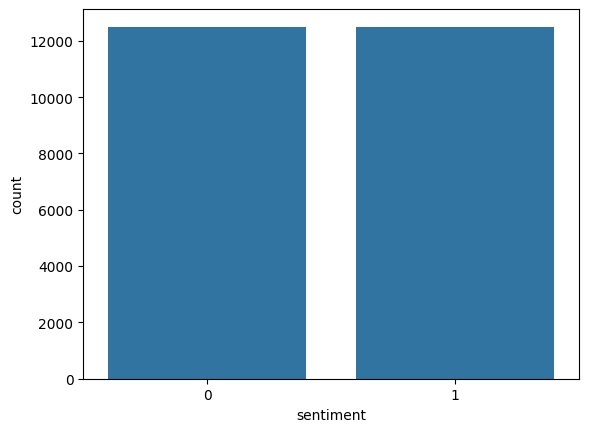

In [7]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [8]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


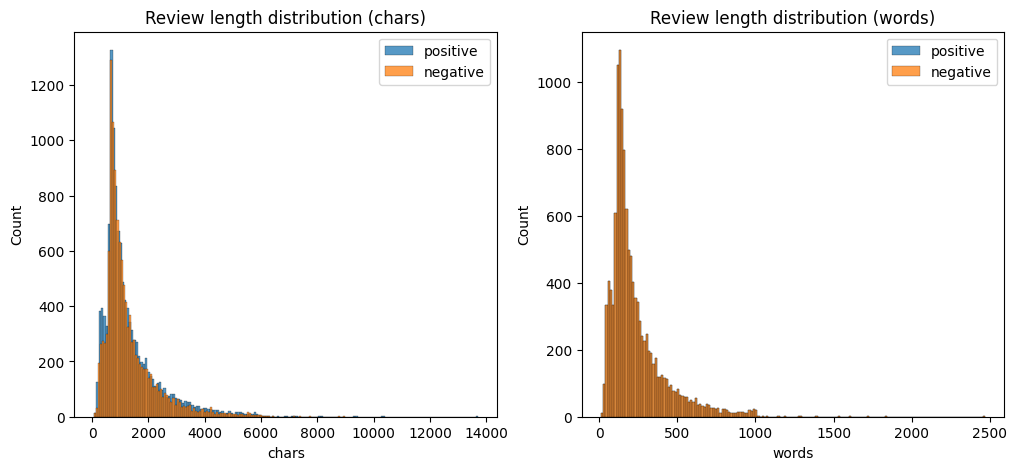

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

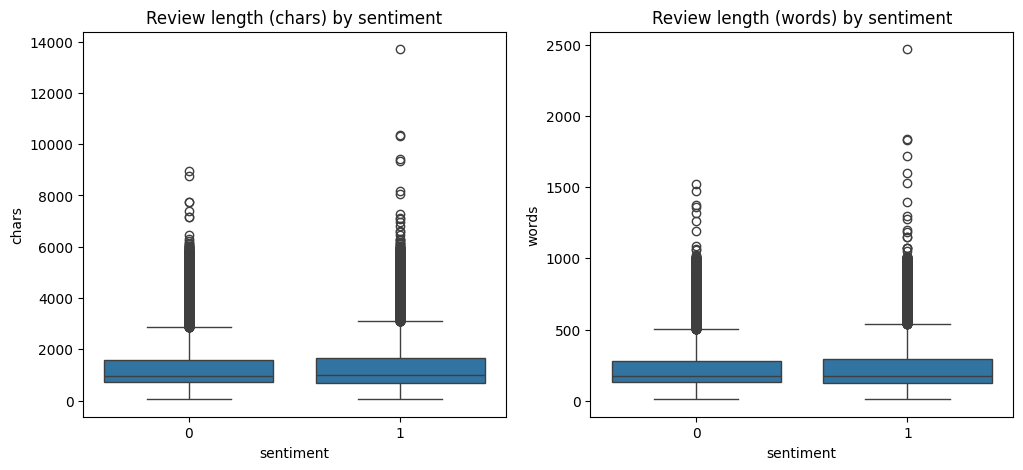

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [11]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [12]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [13]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [15]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [17]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [18]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [19]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [21]:
print(train_df['review'][0])
print(x_train[0])

This is a wonderful movie about the struggle of the Mormons and their final settlement in Salt Lake, Utah. The beginning and the ending are especially powerful, and the message is one we all have to be reminded of - God doesn't talk, but he communicates, if we would only listen. As I am writing this in the midst of the horrors going on in New Orleans and the surrounding area due to Katrina, I was especially moved by the Mormons having to leave everything behind and move on after Joseph Smith was assassinated. People came to this country to escape religious persecution, and yet they could not. The struggle of the Mormons to cross the country, the cost in lives, the hardship they suffered was truly awe-inspiring, demonstrating their tremendous strength. As far as the actual beliefs of Mormons, this is not heavily gone into, and polygamy is mentioned but is not a centerpiece of the film at all.<br /><br />The cast is top-notch, though others who have commented know more about the actual c

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [22]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(1655, 1), (1662, 2), (1717, 1), (4114, 1), (4572, 1), (4694, 1), (5242, 1), (6386, 1), (6594, 1), (6631, 1), (6696, 1), (7240, 1), (8703, 4), (9006, 1), (10247, 1), (10379, 1), (10763, 1), (10870, 1), (10931, 2), (11315, 1), (11355, 1), (11611, 1), (13556, 1), (13627, 1), (14613, 1), (14976, 1), (15032, 2), (15100, 2), (15112, 1), (15681, 1), (15718, 1), (16557, 3), (16575, 1), (16759, 1), (17459, 1), (19396, 1), (19569, 1), (20308, 1), (20742, 1), (21131, 1), (21739, 1), (21764, 1), (22393, 1), (22451, 2), (22687, 1), (22739, 1), (22883, 1), (23375, 1), (23659, 1), (23754, 1), (23906, 1), (23913, 1), (24504, 4), (24535, 1), (24576, 1), (27269, 1), (27584, 1), (27860, 1), (27928, 1), (28013, 1), (29662, 1), (29816, 1), (30317, 1), (31648, 1), (31820, 1), (33820, 1), (34814, 1), (34880, 1), (35390, 1), (35492, 1), (36095, 1), (36509, 1), (36859, 1), (37480, 1), (38089, 1), (38156, 1), (38395, 1), (38792, 1), (38930, 1), (39016, 1), (39528, 1), (40227, 1), (40363, 1), (41120, 1), (4216

The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [23]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

actors: 1
actual: 2
added: 1
area: 1
assassinated: 1
astor: 1
awe: 1
beat: 1
beginning: 1
behind: 1
beliefs: 1
big: 1
br: 4
brian: 1
came: 1
candy: 1
carradine: 1
case: 1
cast: 2
centerpiece: 1
certainly: 1
characters: 1
commented: 1
communicates: 1
conversion: 1
cost: 1
could: 2
country: 2
couple: 1
cross: 1
crowds: 1
darnell: 3
darwell: 1
dean: 1
demonstrating: 1
doesn: 1
donlevy: 1
due: 1
easily: 1
either: 1
end: 1
ending: 1
escape: 1
especially: 2
even: 1
everything: 1
excellently: 1
eye: 1
family: 1
far: 1
fate: 1
father: 1
film: 4
filming: 1
final: 1
get: 1
given: 1
god: 1
going: 1
gone: 1
handsome: 1
hardship: 1
heavily: 1
horrors: 1
however: 1
inspiring: 1
jagger: 1
jane: 1
john: 1
joseph: 1
katrina: 1
killed: 1
know: 1
lake: 1
leave: 1
left: 1
less: 1
linda: 1
listen: 1
lives: 1
lovely: 1
magnificently: 1
make: 1
mary: 1
mentioned: 1
message: 1
midst: 1
mormon: 2
mormons: 5
move: 1
moved: 1
movie: 2
much: 1
new: 1
not: 5
notch: 1
one: 3
orleans: 1
others: 1
people: 1
persecuti

One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [25]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 "Footlight Parade" is just one of several wonderfully jaunty musicals that Warner Bros. produced in the early 1930's to ward off the Depression. "42nd Street" and the Golddiggers series were also produced during this era, and they made literally, millions of Americans forget their troubles for a little while, and enjoy themselves.<br /><br />While most of the films produced had the great talents of Joan Blondell, Ruby Keeler, and Dick Powell, only Foolight Parade had the incomparable James Cagney. Almost ten years prior to his most well-known musical, "Yankee Doodle Dandy". Here he dances in that most original of dance styles, with his arms usually lowered at his side, and his legs doing all types of undulations and kicks. It's easy to see that he is enjoying himself, and that makes us enjoy him all the more.<br /><br />While almost all of the musical sequences appear at the end of the film, they are well worth the wait. I believe that this film was made just prior to

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [27]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [46]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86360,0.998480,0.869813,0.99816,0.85520,0.998320,0.862445


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [47]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

In [48]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    text = normalize_text(text)
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]

    return ' '.join(stemmed_words)

In [49]:
import spacy

nlp = spacy.load('en_core_web_sm')

def lemma_text(text):
    text = normalize_text(text)
    doc = nlp(text)
    lemma_words = [token.lemma_ for token in doc]

    return ' '.join(lemma_words)

In [50]:
# 4 NUEVOS EXPERIMENTOS
experiments = [
    ('CountVectorizer-stem', stem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lemma', lemma_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', stem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lemma', lemma_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer-stem,0.92900,0.87800,0.922144,0.877758,0.93712,0.87832,0.929572,0.878039
3,TfidfVectorizer-lemma,0.93084,0.87760,0.923155,0.876876,0.93992,0.87856,0.931462,0.877717
1,CountVectorizer-lemma,0.99744,0.85832,0.997042,0.865037,0.99784,0.84912,0.997441,0.857004
0,CountVectorizer-stem,0.99680,0.85536,0.997118,0.863562,0.99648,0.84408,0.996799,0.853710


In [51]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,refresh (1.711),erotic (1.587),great (7.127),great (7.379)
#2,flawless (1.599),superb (1.444),excel (6.569),excellent (6.385)
#3,driven (1.491),wonderfully (1.434),love (5.098),love (5.066)
#4,superb (1.445),flawless (1.402),enjoy (5.078),perfect (4.769)
#5,excel (1.437),funniest (1.400),best (4.887),favorite (4.654)
#6,squirrel (1.412),excellent (1.379),perfect (4.865),wonderful (4.569)
#7,erot (1.397),refreshing (1.303),favorit (4.614),good (4.483)
#8,funniest (1.336),favorite (1.262),well (4.072),enjoy (4.353)
#9,whoopi (1.271),serpent (1.248),beauti (4.008),amazing (4.215)



Top 10 negative words across experiments


,CountVectorizer-stem,CountVectorizer-lemma,TfidfVectorizer-stem,TfidfVectorizer-lemma
rank,,,,
#1,worst (-2.036),disappointment (-2.126),worst (-8.940),bad (-10.939)
#2,poorli (-1.859),poorly (-1.781),wast (-7.372),waste (-7.537)
#3,mstk (-1.763),awful (-1.740),bad (-7.163),awful (-6.468)
#4,aw (-1.726),waste (-1.733),aw (-6.595),poor (-5.286)
#5,wast (-1.627),mstk (-1.637),bore (-6.040),boring (-5.249)
#6,unfunni (-1.549),lousy (-1.507),poor (-5.338),nothing (-4.924)
#7,forgett (-1.539),unfunny (-1.501),disappoint (-4.688),terrible (-4.740)
#8,unwatch (-1.515),dreadful (-1.453),noth (-4.685),no (-4.507)
#9,alright (-1.501),alright (-1.427),terribl (-4.666),fail (-4.372)


#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

En este caso, TfidfVectorizer-stem fue el mejor modelo con un accuracy_test de 0.87800, sin embargo, con los anteriores modelos sigue siendo superado por TfidfVectorizer y TfidfVectorizer-norm. Esto indica una clara mejoría general de TF-IDF en comparación con los modelos con CountVectorizer, demostrando su naturaleza. Ya que generalizan ligeramente mejor, mientras que stemming reduce el vocabulario y ayuda a generalizar, por otro lado, lemmatization, aunque es más preciso, da una menor comprensión.

En comparación con los top features de los cuatro diferentes modelos, se puede apreciar que en los modelos con stem a veces se encuentran palabras que no se entienden tanto, como poorli, aw o wors, debido a que están truncadas y son menos interpretables. Pero del lado de TF-IDF, por ejemplo, en el caso de reseñas positivas concuerdan con “great” o en las negativas con “awful” en tercera posición, dando una mejor interpretación y comparación.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

In [67]:
# Reseña propia
review = "I recently watched Project Hail Mary in the cinema. It was amazing, with truly beautiful shots and great, iconic characters throughout the film. It presents a different way to establish relationships between humans and aliens, where the only thing they share is a mission and a purpose to help their species—that is hope."

# Buscar mejor modelo segun accuraccy_test
best_run = next(r for r in model_runs if r['name'] == 'TfidfVectorizer-stem')
best_model = best_run['model']
best_vectorizer = best_run['fitted_vectorizer']

# Pasos para predecir
processed_review = stem_text(review)
review_vec = best_vectorizer.transform([processed_review])
prediction = best_model.predict(review_vec)[0]

print("Predicción:", "Positive" if prediction == 1 else "Negative")

Predicción: Positive


Considero que la predicción es correcta debido a las palabras clave que usé para describirla, como “beautiful”, “great” o “amazing”, ya que considero que la película tuvo un poco de todo y, sin duda, el modelo logra capturar la esencia según las palabras clave que estuvieron en el top del análisis pasado.

#### Write your final remarks on this activity.

A lo largo de esta actividad me pude dar cuenta de una de las bases que hoy está revolucionando y ha cambiado al mundo a través de los años pasados: el Natural Language Processing, algo que ha ayudado a los modelos de IA a llegar a las herramientas que son hoy en día. Así como la comparación más visual en la tabla de stem contra lemma, donde a veces se sacrifica cierta comprensión por generalización o viceversa, dependiendo del contexto. Además, en esta actividad el dataset me pareció adecuado e interesante, debido a que soy alguien que ve muchas películas, así que aplicarlas con conocimientos de la carrera ayuda a resguardar mejor la información adquirida. Para finalizar, considero que a futuro se puede comparar con más variaciones o relacionado para verificar cuál es la mejor combinación y alcanzar un mayor accuracy en el modelo y usarlo para seguir comparando texto, quizá ahora en otro contexto como reseñas en línea de un producto o comentarios de un video de YouTube; tiene muchas aplicaciones para un ejemplo como este.